In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_parquet("../data/raw/final_sample.parquet")

In [5]:
df.shape

(7947995, 28)

In [6]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,source_file,sample_year,sample_month,month_total_rows,month_sample_rows,target_sample_frac,actual_sample_frac,cap_was_applied,Airport_fee
0,2,2023-01-29 17:52:02,2023-01-29 17:56:43,1.0,1.17,1.0,N,262,74,2,7.2,0.0,0.5,0.00,0.0,1.0,11.20,2.5,0.0,yellow_tripdata_2023-01.parquet,2023,1,3066766,306677,0.1,0.1,False,NaN
1,1,2023-01-08 15:57:24,2023-01-08 16:02:47,1.0,0.90,1.0,N,229,237,2,6.5,2.5,0.5,0.00,0.0,1.0,10.50,2.5,0.0,yellow_tripdata_2023-01.parquet,2023,1,3066766,306677,0.1,0.1,False,NaN
2,2,2023-01-21 19:38:01,2023-01-21 19:45:02,1.0,0.95,1.0,N,45,261,1,7.9,0.0,0.5,2.38,0.0,1.0,14.28,2.5,0.0,yellow_tripdata_2023-01.parquet,2023,1,3066766,306677,0.1,0.1,False,NaN
3,2,2023-01-23 16:07:31,2023-01-23 16:26:46,5.0,0.88,1.0,N,237,141,1,16.3,2.5,0.5,1.50,0.0,1.0,24.30,2.5,0.0,yellow_tripdata_2023-01.parquet,2023,1,3066766,306677,0.1,0.1,False,NaN
4,2,2023-01-26 21:21:08,2023-01-26 21:24:48,2.0,1.03,1.0,N,229,140,1,6.5,1.0,0.5,2.30,0.0,1.0,13.80,2.5,0.0,yellow_tripdata_2023-01.parquet,2023,1,3066766,306677,0.1,0.1,False,NaN


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7947995 entries, 0 to 7947994
Data columns (total 28 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            float64   

In [8]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,sample_year,sample_month,month_total_rows,month_sample_rows,target_sample_frac,actual_sample_frac,Airport_fee
count,7.947995e+06,7947995,7947995,7.407909e+06,7.947995e+06,7.407909e+06,7.947995e+06,7.947995e+06,7.947995e+06,7.947995e+06,7.947995e+06,7.947995e+06,7.947995e+06,7.947995e+06,7.947995e+06,7.947995e+06,7.407909e+06,299575.000000,7.947995e+06,7.947995e+06,7.947995e+06,7.947995e+06,7947995.0,7.947995e+06,7.108334e+06
mean,1.752192e+00,2024-01-10 07:54:32.324661,2024-01-10 08:12:00.284795,1.352212e+00,4.367905e+00,1.980492e+00,1.646828e+02,1.636688e+02,1.144172e+00,1.942066e+01,1.468149e+00,4.826085e-01,3.412442e+00,5.756590e-01,9.709276e-01,2.816833e+01,2.248222e+00,0.107924,2.023518e+03,6.604047e+00,3.340158e+06,3.340158e+05,0.1,1.000000e-01,1.452145e-01
min,1.000000e+00,2001-01-01 00:28:40,2001-01-01 01:11:09,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-9.990000e+02,-7.500000e+00,-5.000000e-01,-9.235000e+01,-7.330000e+01,-1.000000e+00,-1.000000e+03,-2.500000e+00,-1.250000,2.023000e+03,1.000000e+00,2.824209e+06,2.824210e+05,0.1,9.999986e-02,-1.750000e+00
25%,2.000000e+00,2023-07-06 10:39:08.500000,2023-07-06 10:54:32,1.000000e+00,1.020000e+00,1.000000e+00,1.320000e+02,1.130000e+02,1.000000e+00,9.300000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.580000e+01,2.500000e+00,0.000000,2.023000e+03,4.000000e+00,3.007526e+06,3.007530e+05,0.1,9.999992e-02,0.000000e+00
50%,2.000000e+00,2024-01-16 18:12:55,2024-01-16 18:26:53,1.000000e+00,1.770000e+00,1.000000e+00,1.610000e+02,1.620000e+02,1.000000e+00,1.350000e+01,1.000000e+00,5.000000e-01,2.720000e+00,0.000000e+00,1.000000e+00,2.100000e+01,2.500000e+00,0.000000,2.024000e+03,6.000000e+00,3.376567e+06,3.376570e+05,0.1,1.000000e-01,0.000000e+00
75%,2.000000e+00,2024-07-11 21:46:33.500000,2024-07-11 22:03:24.500000,1.000000e+00,3.390000e+00,1.000000e+00,2.330000e+02,2.340000e+02,1.000000e+00,2.235000e+01,2.500000e+00,5.000000e-01,4.340000e+00,0.000000e+00,1.000000e+00,3.062000e+01,2.500000e+00,0.000000,2.024000e+03,1.000000e+01,3.582628e+06,3.582630e+05,0.1,1.000001e-01,0.000000e+00
max,7.000000e+00,2024-12-31 23:59:05,2025-01-01 16:26:48,9.000000e+00,3.663430e+05,9.900000e+01,2.650000e+02,2.650000e+02,5.000000e+00,3.355444e+05,1.650000e+01,5.316000e+01,9.999900e+02,3.550000e+02,2.000000e+00,3.355509e+05,2.500000e+00,1.250000,2.024000e+03,1.200000e+01,3.833771e+06,3.833770e+05,0.1,1.000002e-01,1.750000e+00
std,4.349567e-01,NaN,NaN,8.555533e-01,3.200788e+02,9.341241e+00,6.416677e+01,6.972234e+01,6.082220e-01,1.205384e+02,1.830976e+00,1.214014e-01,4.116718e+00,2.215797e+00,2.299392e-01,1.213803e+02,8.371343e-01,0.356447,4.996763e-01,3.452417e+00,3.039456e+05,3.039451e+04,0.0,9.224725e-08,4.906232e-01


In [9]:
df["trip_duration_min"] = (
    df["tpep_dropoff_datetime"] -
    df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

In [10]:
df["trip_duration_min"].describe()

count    7.947995e+06
mean     1.746600e+01
std      3.756142e+01
min     -5.593333e+01
25%      7.733333e+00
50%      1.283333e+01
75%      2.091667e+01
max      6.636450e+03
Name: trip_duration_min, dtype: float64

In [11]:
df_clean = df[
    df["trip_duration_min"] >= 0
].copy()

In [12]:
df_clean["trip_duration_min"].describe()

count    7.947588e+06
mean     1.746790e+01
std      3.756113e+01
min      0.000000e+00
25%      7.733333e+00
50%      1.283333e+01
75%      2.091667e+01
max      6.636450e+03
Name: trip_duration_min, dtype: float64

In [14]:
df_clean["trip_duration_min"].quantile([
    0.90,
    0.95,
    0.99,
    0.999
])

0.900     32.833333
0.950     43.666667
0.990     69.366667
0.999    125.966667
Name: trip_duration_min, dtype: float64

In [15]:
df_clean[
    df_clean["trip_duration_min"] > 300
][[
    "trip_duration_min",
    "trip_distance",
    "fare_amount",
    "total_amount"
]].head(20)

,trip_duration_min,trip_distance,fare_amount,total_amount
36,1434.050000,5.96,39.4,45.57
909,1422.600000,3.63,19.1,30.12
3836,1421.816667,0.45,5.1,10.46
3986,1402.850000,7.26,41.5,45.50
4090,1437.733333,0.49,5.1,10.10
9425,1418.233333,18.33,70.0,90.94
12033,705.400000,10.90,45.7,62.50
13097,1416.983333,1.35,10.0,17.50
14396,1434.916667,0.69,5.8,10.78
16165,1410.150000,7.44,34.5,41.00


In [16]:
df_clean = df_clean[
    df_clean["trip_duration_min"] <= 180
].copy()

In [17]:
df_clean["trip_duration_min"].describe()

count    7.941496e+06
mean     1.656377e+01
std      1.353546e+01
min      0.000000e+00
25%      7.733333e+00
50%      1.283333e+01
75%      2.088333e+01
max      1.799833e+02
Name: trip_duration_min, dtype: float64

In [18]:
df_clean["speed_mph"] = df_clean["trip_distance"] / (df_clean["trip_duration_min"] / 60)

In [19]:
df_clean[df_clean["speed_mph"] > 80][
    ["trip_distance", "trip_duration_min", "speed_mph"]
].head(20)

,trip_distance,trip_duration_min,speed_mph
1161,9.90,0.133333,4455.000000
4522,23.93,17.700000,81.118644
5423,10.44,0.183333,3416.727273
6764,4.40,0.000000,inf
9260,3.00,0.183333,981.818182
9408,0.07,0.050000,84.000000
12718,9.90,0.133333,4455.000000
12776,2.20,0.300000,440.000000
13998,10.50,0.483333,1303.448276
15053,0.18,0.033333,324.000000


In [20]:
df_clean = df_clean[df_clean["trip_duration_min"] > 0].copy()

In [21]:
df_clean["speed_mph"] = df_clean["trip_distance"] / (df_clean["trip_duration_min"] / 60)

In [22]:
df_clean = df_clean[df_clean["speed_mph"] <= 80]

In [23]:
df_clean["speed_mph"].describe()

count    7.935798e+06
mean     1.092498e+01
std      6.626063e+00
min      0.000000e+00
25%      6.863952e+00
50%      9.376206e+00
75%      1.300699e+01
max      8.000000e+01
Name: speed_mph, dtype: float64

In [24]:
df_clean["hour"] = df_clean["tpep_pickup_datetime"].dt.hour

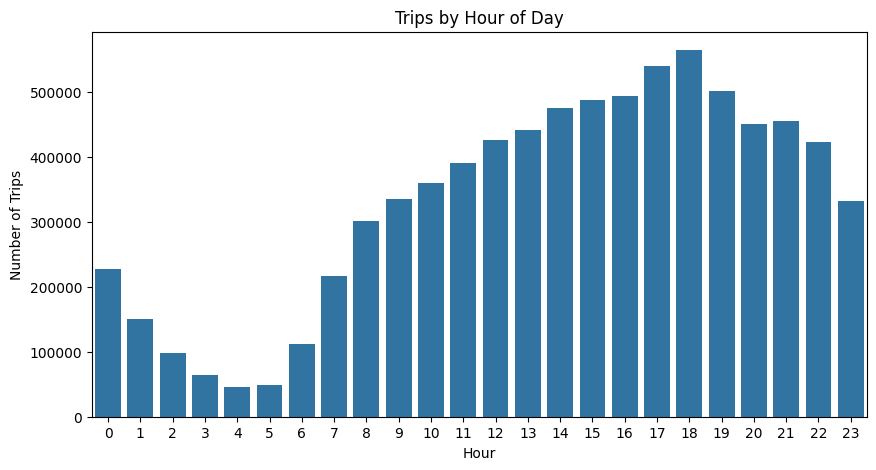

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.countplot(
    x=df_clean["hour"]
)

plt.title("Trips by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Trips")

plt.show()

In [26]:
df_clean["day_of_week"] = df_clean["tpep_pickup_datetime"].dt.day_name()

In [27]:
df_clean["passenger_count"].value_counts().sort_index()

passenger_count
0.0      97425
1.0    5638969
2.0    1099310
3.0     266760
4.0     160901
5.0      79909
6.0      53207
7.0         15
8.0         36
9.0          6
Name: count, dtype: int64

In [29]:
df_clean = df_clean[df_clean["passenger_count"] >= 1]
df_clean = df_clean[df_clean["passenger_count"] <= 6]

In [30]:
df_clean["passenger_count"].describe()

count    7.299056e+06
mean     1.370076e+00
std      8.459577e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      6.000000e+00
Name: passenger_count, dtype: float64

In [ ]:
zones = pd.read_csv("taxi_zone_lookup.csv")
zones.head()

In [39]:
df_clean["fare_amount"].describe()

count    7.126615e+06
mean     1.897029e+01
std      1.570169e+01
min      1.000000e-02
25%      9.300000e+00
50%      1.350000e+01
75%      2.190000e+01
max      8.000000e+01
Name: fare_amount, dtype: float64

In [40]:
df_clean["tip_amount"].describe()

count    7.126615e+06
mean     3.525115e+00
std      3.850208e+00
min      0.000000e+00
25%      1.000000e+00
50%      2.860000e+00
75%      4.420000e+00
max      9.999900e+02
Name: tip_amount, dtype: float64

In [36]:
df_clean = df_clean[df_clean["fare_amount"] >= 0].copy()

In [32]:
df_clean["fare_amount"].quantile([0.90, 0.95, 0.99, 0.999])

0.900     42.2
0.950     70.0
0.990     80.0
0.999    150.7
Name: fare_amount, dtype: float64

In [34]:
df_clean = df_clean[df_clean["fare_amount"] <= 80]

In [38]:
df_clean = df_clean[df_clean["fare_amount"] > 0]

In [41]:
df_clean = df_clean[
    df_clean["tpep_dropoff_datetime"] > df_clean["tpep_pickup_datetime"]
].copy()

In [42]:
df_clean = df_clean[
    (df_clean["total_amount"] >= 0) &
    (df_clean["total_amount"] <= 400)
]

In [43]:
df_clean = df_clean[df_clean["VendorID"].isin([1,2,6,7])]

In [44]:
df_clean = df_clean[df_clean["payment_type"].isin([0,1,2,3,4,5,6])]

In [45]:
df_clean = df_clean[df_clean["RatecodeID"].isin([1,2,3,4,5,6,99])]

In [49]:
df_clean.info()
df_clean.describe()

<class 'pandas.DataFrame'>
Index: 7126609 entries, 0 to 7947994
Data columns (total 33 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            float64       


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,sample_year,sample_month,month_total_rows,month_sample_rows,target_sample_frac,actual_sample_frac,Airport_fee,trip_duration_min,speed_mph,hour
count,7.126609e+06,7126609,7126609,7.126609e+06,7.126609e+06,7.126609e+06,7.126609e+06,7.126609e+06,7.126609e+06,7.126609e+06,7.126609e+06,7.126609e+06,7.126609e+06,7.126609e+06,7.126609e+06,7.126609e+06,7.126609e+06,289450.000000,7.126609e+06,7.126609e+06,7.126609e+06,7.126609e+06,7126609.0,7.126609e+06,6.837159e+06,7.126609e+06,7.126609e+06,7.126609e+06
mean,1.758289e+00,2024-01-02 14:07:18.036380,2024-01-02 14:23:34.567321,1.367715e+00,3.281214e+00,1.975634e+00,1.653702e+02,1.645546e+02,1.196817e+00,1.897028e+01,1.587188e+00,4.975503e-01,3.524598e+00,5.401997e-01,9.957367e-01,2.801387e+01,2.325577e+00,0.107691,2.023500e+03,6.567656e+00,3.332639e+06,3.332639e+05,0.1,1.000000e-01,1.453757e-01,1.627552e+01,1.085311e+01,1.434442e+01
min,1.000000e+00,2001-01-01 00:28:40,2001-01-01 01:11:09,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e-02,-2.500000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.010000e+00,0.000000e+00,0.000000,2.023000e+03,1.000000e+00,2.824209e+06,2.824210e+05,0.1,9.999986e-02,0.000000e+00,1.666667e-02,0.000000e+00,0.000000e+00
25%,2.000000e+00,2023-06-26 09:18:38,2023-06-26 09:35:29,1.000000e+00,1.020000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,9.300000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.596000e+01,2.500000e+00,0.000000,2.023000e+03,4.000000e+00,3.007526e+06,3.007530e+05,0.1,9.999992e-02,0.000000e+00,7.616667e+00,6.883249e+00,1.100000e+01
50%,2.000000e+00,2023-12-31 21:16:06,2023-12-31 21:29:10,1.000000e+00,1.730000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.350000e+01,1.000000e+00,5.000000e-01,2.860000e+00,0.000000e+00,1.000000e+00,2.100000e+01,2.500000e+00,0.000000,2.023000e+03,6.000000e+00,3.376567e+06,3.376570e+05,0.1,1.000000e-01,0.000000e+00,1.256667e+01,9.342857e+00,1.500000e+01
75%,2.000000e+00,2024-07-02 17:47:45,2024-07-02 18:04:11,1.000000e+00,3.260000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.190000e+01,2.500000e+00,5.000000e-01,4.420000e+00,0.000000e+00,1.000000e+00,3.030000e+01,2.500000e+00,0.000000,2.024000e+03,1.000000e+01,3.582628e+06,3.582630e+05,0.1,1.000001e-01,0.000000e+00,2.050000e+01,1.287977e+01,1.900000e+01
max,2.000000e+00,2024-12-31 23:58:03,2025-01-01 00:33:36,6.000000e+00,7.050000e+01,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,8.000000e+01,1.425000e+01,4.000000e+00,3.030000e+02,3.550000e+02,1.000000e+00,3.715000e+02,2.500000e+00,1.250000,2.024000e+03,1.200000e+01,3.833771e+06,3.833770e+05,0.1,1.000002e-01,1.750000e+00,1.799833e+02,8.000000e+01,2.300000e+01
std,4.281203e-01,NaN,NaN,8.450514e-01,4.169586e+00,9.435973e+00,6.356640e+01,6.900040e+01,4.729760e-01,1.570169e+01,1.824055e+00,3.511867e-02,3.804717e+00,1.926577e+00,6.474814e-02,2.023563e+01,6.368943e-01,0.350738,5.000000e-01,3.464509e+00,3.033901e+05,3.033896e+04,0.0,9.312457e-08,4.781306e-01,1.322123e+01,6.338846e+00,5.747219e+00


In [47]:
df_clean["is_free_ride"] = df_clean["fare_amount"] == 0

In [48]:
df_clean[df_clean["tip_amount"] > 100][
    ["tip_amount", "fare_amount", "total_amount"]
].head()

,tip_amount,fare_amount,total_amount
70921,200.00,19.8,224.80
329619,100.11,20.5,124.61
345452,260.00,3.0,267.00
346385,210.00,33.8,247.80
358504,151.00,3.7,158.70
